# ComplexHeatmap simple quickstart method

In [1]:
# quick-start guide for plotting a DGE heatmap from a DGE table and a relative expression table via ComplexHeatmap
# full user-guide can be found here: https://jokergoo.github.io/ComplexHeatmap-reference/book/

library(ComplexHeatmap)
library(circlize)

Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements a

In [164]:
# Load and view THESC normalized count data
df <- read.csv("250329_VehHeatmap_THESC_final.csv")
head(df)


,Annotation,Gene,THESCNT1,THESCNT2,THESCNT3,THESCSRF1,THESCSRF2,THESCSRF3
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Cytoskeleton and contractility,ACTB,465759.1070,496230.5774,504609.9778,298682.78140,317256.13830,319930.38230
2,Cytoskeleton and contractility,ACTG2,824.1436,877.5639,735.0352,59.06782,83.74972,60.74812
3,Cytoskeleton and contractility,CNN1,10447.9257,10908.8474,10415.3772,1047.00599,1163.55194,1175.85057
4,Cytoskeleton and contractility,ACTA2,72931.2594,74870.4202,71034.3709,8508.08188,8856.32968,8403.21234
5,Cytoskeleton and contractility,DES,265.9406,208.1179,195.0579,84.54805,82.93662,82.38443
6,Cytoskeleton and contractility,ACTN1,73041.0847,73715.3658,73702.1442,32385.37783,33823.50368,33827.54819


In [165]:
# center and scale the rlog counts table (i.e. produce Z-score expression values across the samples, for each gene)
# note: t() will transpose the matrix, and we are specifying that we are only taking the data starting in the 3rd column
# so, here, we are transposing the matrix, center and scaling with scale(), then transposing back
# the reason for this is that scale() by default wants to scale each column vector (samples here), but we want to scale gene-wise

heat <- t(scale(t(df[,3:ncol(df)])))
rownames(heat) <- df$Gene # assign row names as gene names
head(heat) # check our work

,THESCNT1,THESCNT2,THESCNT3,THESCSRF1,THESCSRF2,THESCSRF3
ACTB,0.6666064,0.9774437,1.0629213,-1.0377274,-0.8482619,-0.8209821
ACTG2,0.9360144,1.0661972,0.7188615,-0.9284389,-0.8682902,-0.9243441
CNN1,0.8847834,0.9736677,0.8785067,-0.9280930,-0.9056183,-0.9032466
ACTA2,0.9119231,0.9669027,0.8581419,-0.9146227,-0.9047491,-0.9175960
DES,1.4065569,0.6853871,0.5225012,-0.8557875,-0.8758855,-0.8827723
ACTN1,0.8923155,0.9229736,0.9223724,-0.9562073,-0.8908190,-0.8906351


In [166]:
# Export scaled normalized counts file if desired

write.csv(heat,file="250329_heat_scaled.norm.counts_THESC_final.csv") # keeps the rownames


In [167]:
# Set annotations
  ColAnn <- data.frame(colnames(heat))
  colnames(ColAnn) <- c("Sample")
  ColAnn <- HeatmapAnnotation(df=ColAnn, which="col")

RowAnn <- data.frame(df$Annotation)
  colnames(RowAnn) <- c("Annotation")
  colours <- list("Annotation"=c("Extracellular matrix"="yellow", "Growth response and proliferation"="slateblue", "Cytoskeleton and contractility"="deepskyblue"))
  RowAnn <- HeatmapAnnotation(df=RowAnn, col=colours, which="row")

myBreaks <- seq(-3, 3, length.out=100)
myCol <- colorRampPalette(c("blue", "white", "red"))(100)


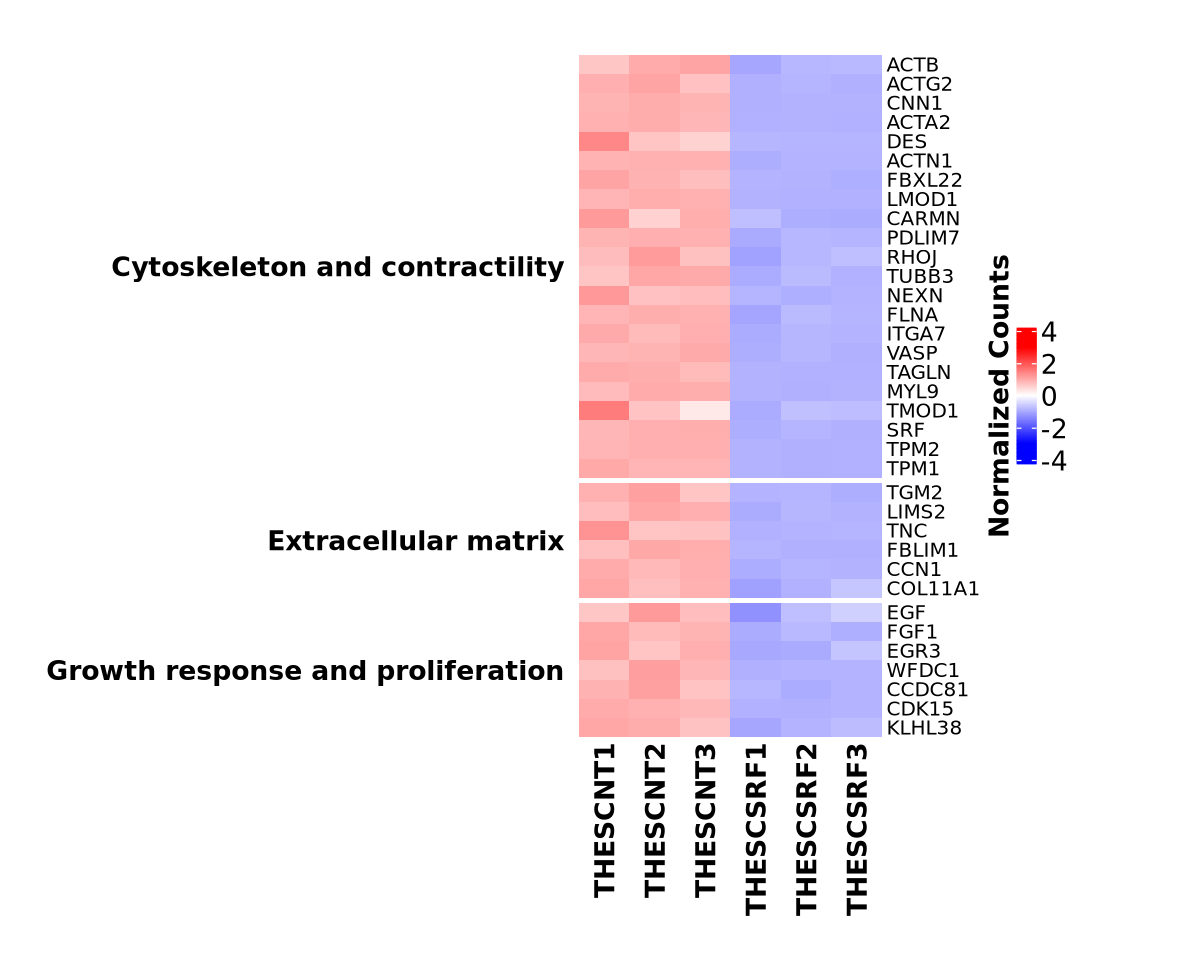

In [168]:
# draw without right side annotation, adding all row titles instead

saved <- options(repr.plot.width = 10, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

set.seed(123)
#Set annotation parameters

RowAnn <- data.frame(df$Annotation)
  colnames(RowAnn) <- c("Annotation")
  colours <- list("Annotation"=c( "Extracellular matrix"="yellow", "Growth response and proliferation"="slateblue", "Cytoskeleton and contractility"="deepskyblue"))
  RowAnn <- HeatmapAnnotation(df=RowAnn, 
                              col=colours,
                              annotation_name_gp = gpar(fontsize = 16, fontface = "bold"),
                              which="row",
                              annotation_legend_param = list(
                                                title_gp = gpar(fontsize = 16, fontface = "bold"), 
                                                labels_gp = gpar(fontsize = 16)))

myBreaks <- seq(-3, 3, length.out=100)
myCol <- colorRampPalette(c("blue", "white", "red"))(100)

#Set heatmap parameters
hmap <- Heatmap(heat,
        name="Normalized Counts",
        col=colorRamp2(myBreaks, myCol),
        heatmap_width = unit(18,"cm"),
        heatmap_height = unit(18,"cm"),
        column_names_gp = gpar(fontsize = 16, fontface="bold"),
        heatmap_legend_param = list(
            color_bar = "continuous",
            legend_direction = "vertical",
            legend_width = unit(7, "cm"),
            title_position = "leftcenter-rot",
            title_gp = gpar(fontsize = 16, fontface = "bold"),
            labels_gp = gpar(fontsize = 16)),

        #Keep row order instead of clustering
        #row_order = order(as.numeric(gsub("row", "", rownames(heat)))),
        #Keep column order instead of clustering
        #column_order = order(as.numeric(gsub("column", "", colnames(heat)))),
                
        #Split heatmap rows by annotation
        split=df$Annotation,

        #Row annotation configurations
        cluster_rows=FALSE,
        show_row_dend=FALSE,
        row_title_side="left",
        row_title_gp=gpar(fontsize=16, fontface="bold"),
        show_row_names=TRUE,
        row_names_side="right",
        row_names_gp=gpar(fontsize=12),
        row_names_rot=0,
        row_title_rot=0,

        #Column annotation configuratiions
        cluster_columns=FALSE,
        show_column_dend=FALSE,
        column_title="",
        column_title_side="top",
        column_title_gp=gpar(fontsize=15, fontface="bold"),
        column_title_rot=0,
        show_column_names=TRUE,

        
                
        #Dendrogram configurations: rows
        #clustering_distance_rows="euclidean",
        #clustering_method_rows="ward.D2",
        #row_dend_width=unit(10,"mm")
        )

        #Annotations (row annotation must be added with 'draw' function, below)
        


draw(hmap, heatmap_legend_side="right")

options(saved) # restore old settings

Warning message in order(as.numeric(gsub("column", "", colnames(heat)))):
“NAs introduced by coercion”


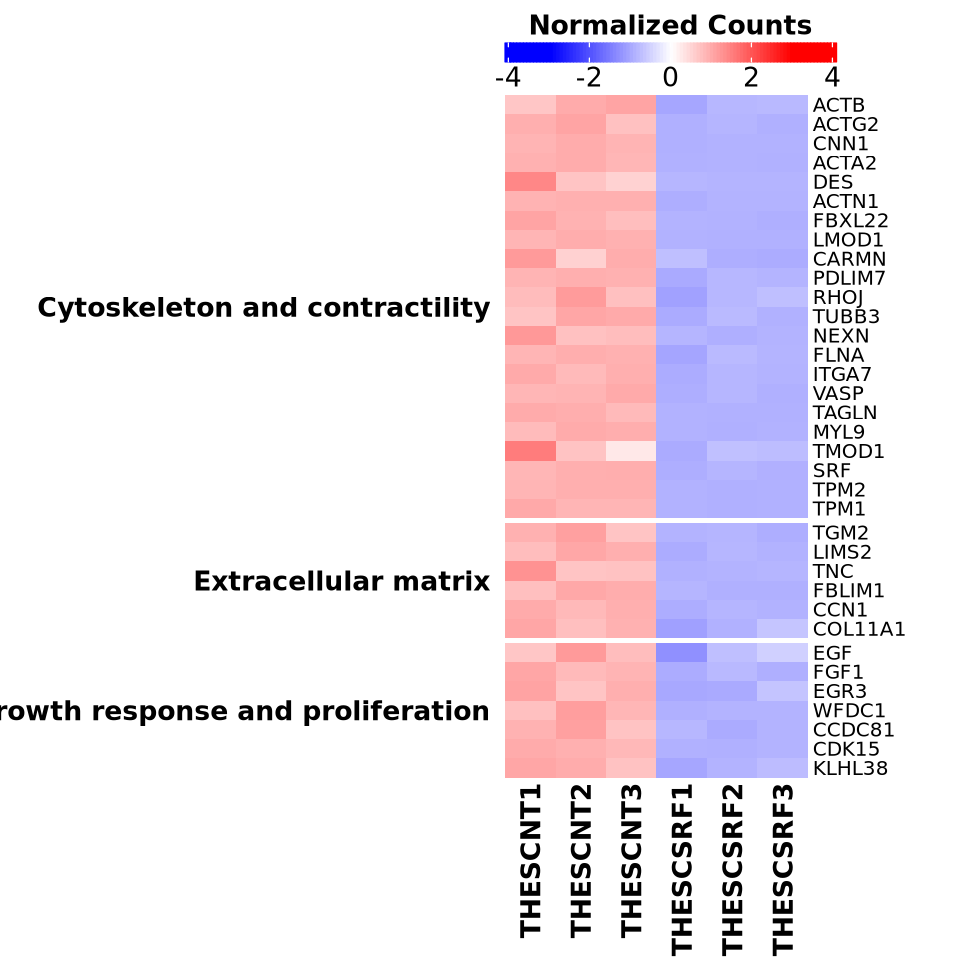

In [169]:
#another version with rotated legend
# draw without right side annotation, adding all row titles instead

saved <- options(repr.plot.width = 8, repr.plot.height = 8) # Make the plots bigger from here on out, save old options

set.seed(123)
#Set annotation parameters

RowAnn <- data.frame(df$Annotation)
  colnames(RowAnn) <- c("Annotation")
  colours <- list("Annotation"=c( "Extracellular matrix"="yellow", "Growth response and proliferation"="slateblue", "Cytoskeleton and contractility"="deepskyblue"))
  RowAnn <- HeatmapAnnotation(df=RowAnn, 
                              col=colours,
                              annotation_name_gp = gpar(fontsize = 16, fontface = "bold"),
                              which="row",
                              annotation_legend_param = list(
                                                title_gp = gpar(fontsize = 16, fontface = "bold"), 
                                                labels_gp = gpar(fontsize = 16)))

myBreaks <- seq(-3, 3, length.out=100)
myCol <- colorRampPalette(c("blue", "white", "red"))(100)

#Set heatmap parameters
hmap <- Heatmap(heat,
        name="Normalized Counts",
        col=colorRamp2(myBreaks, myCol),
        heatmap_width = unit(18,"cm"),
        heatmap_height = unit(18,"cm"),
        column_names_gp = gpar(fontsize = 16, fontface="bold"),
        heatmap_legend_param=list(color_bar="continuous", 
            legend_direction="horizontal", 
            legend_width=unit(7,"cm"), 
            title_position="topcenter", 
            title_gp=gpar(fontsize=16, fontface="bold"),
            labels_gp=gpar(fontsize=16)),

        #Keep column order instead of clustering
        column_order = order(as.numeric(gsub("column", "", colnames(heat)))),
                
        #Split heatmap rows by annotation
        split=df$Annotation,

        #Row annotation configurations
        cluster_rows=FALSE,
        show_row_dend=FALSE,
        row_title_side="left",
        row_title_gp=gpar(fontsize=16, fontface="bold"),
        show_row_names=TRUE,
        row_names_side="right",
        row_names_gp=gpar(fontsize=12),
        row_names_rot=0,
        row_title_rot=0,

        #Column annotation configuratiions
        cluster_columns=FALSE,
        show_column_dend=FALSE,
        column_title="",
        column_title_side="top",
        column_title_gp=gpar(fontsize=15, fontface="bold"),
        column_title_rot=0,
        show_column_names=TRUE,

        
                
        #Dendrogram configurations: rows
        #clustering_distance_rows="euclidean",
        #clustering_method_rows="ward.D2",
        #row_dend_width=unit(10,"mm")
        )

        #Annotations (row annotation must be added with 'draw' function, below)
        


draw(hmap, heatmap_legend_side="top")

options(saved) # restore old settings